## EDA

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture 
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, confusion_matrix, davies_bouldin_score, calinski_harabasz_score
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import umap

In [2]:
data = pd.read_csv("D:/hcmus/s8/kltn/icmr/ICMR Datasets/data.csv")
labels = pd.read_csv("D:/hcmus/s8/kltn/icmr/ICMR Datasets/labels.csv")

In [3]:
df = pd.merge(data, labels)
df

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.000000,PRAD
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.000000,LUAD
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.000000,PRAD
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.000000,PRAD
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.000000,BRCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,sample_796,0.0,1.865642,2.718197,7.350099,10.006003,0.0,6.764792,0.496922,0.0,...,9.118313,10.004852,4.484415,9.614701,12.031267,9.813063,10.092770,8.819269,0.000000,BRCA
797,sample_797,0.0,3.942955,4.453807,6.346597,10.056868,0.0,7.320331,0.000000,0.0,...,9.623335,9.823921,6.555327,9.064002,11.633422,10.317266,8.745983,9.659081,0.000000,LUAD
798,sample_798,0.0,3.249582,3.707492,8.185901,9.504082,0.0,7.536589,1.811101,0.0,...,8.610704,10.485517,3.589763,9.350636,12.180944,10.681194,9.466711,4.677458,0.586693,COAD
799,sample_799,0.0,2.590339,2.787976,7.318624,9.987136,0.0,9.213464,0.000000,0.0,...,8.605387,11.004677,4.745888,9.626383,11.198279,10.335513,10.400581,5.718751,0.000000,PRAD


In [4]:
df["Unnamed: 0"] = df["Class"]
df = df.drop(columns = "Class")
df

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,PRAD,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.000000
1,LUAD,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.000000
2,PRAD,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.000000
3,PRAD,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.000000
4,BRCA,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,BRCA,0.0,1.865642,2.718197,7.350099,10.006003,0.0,6.764792,0.496922,0.0,...,6.088133,9.118313,10.004852,4.484415,9.614701,12.031267,9.813063,10.092770,8.819269,0.000000
797,LUAD,0.0,3.942955,4.453807,6.346597,10.056868,0.0,7.320331,0.000000,0.0,...,6.371876,9.623335,9.823921,6.555327,9.064002,11.633422,10.317266,8.745983,9.659081,0.000000
798,COAD,0.0,3.249582,3.707492,8.185901,9.504082,0.0,7.536589,1.811101,0.0,...,5.719386,8.610704,10.485517,3.589763,9.350636,12.180944,10.681194,9.466711,4.677458,0.586693
799,PRAD,0.0,2.590339,2.787976,7.318624,9.987136,0.0,9.213464,0.000000,0.0,...,5.785237,8.605387,11.004677,4.745888,9.626383,11.198279,10.335513,10.400581,5.718751,0.000000


In [5]:
df.isnull().sum()

Unnamed: 0    0
gene_0        0
gene_1        0
gene_2        0
gene_3        0
             ..
gene_20526    0
gene_20527    0
gene_20528    0
gene_20529    0
gene_20530    0
Length: 20532, dtype: int64

In [6]:
df['Unnamed: 0'].value_counts()

Unnamed: 0
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

In [7]:
df.describe()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.0,801.000000,801.000000,801.000000,801.000000,...,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000
mean,0.026642,3.010909,3.095350,6.722305,9.813612,0.0,7.405509,0.499882,0.016744,0.013428,...,5.896573,8.765891,10.056252,4.847727,9.741987,11.742228,10.155271,9.590726,5.528177,0.095411
std,0.136850,1.200828,1.065601,0.638819,0.506537,0.0,1.108237,0.508799,0.133635,0.204722,...,0.746399,0.603176,0.379278,2.382728,0.533898,0.670371,0.580569,0.563849,2.073859,0.364529
min,0.000000,0.000000,0.000000,5.009284,8.435999,0.0,3.930747,0.000000,0.000000,0.000000,...,2.853517,6.678368,8.669456,0.000000,7.974942,9.045255,7.530141,7.864533,0.593975,0.000000
25%,0.000000,2.299039,2.390365,6.303346,9.464466,0.0,6.676042,0.000000,0.000000,0.000000,...,5.454926,8.383834,9.826027,3.130750,9.400747,11.315857,9.836525,9.244219,4.092385,0.000000
50%,0.000000,3.143687,3.127006,6.655893,9.791599,0.0,7.450114,0.443076,0.000000,0.000000,...,5.972582,8.784144,10.066385,5.444935,9.784524,11.749802,10.191207,9.566511,5.218618,0.000000
75%,0.000000,3.883484,3.802534,7.038447,10.142324,0.0,8.121984,0.789354,0.000000,0.000000,...,6.411292,9.147136,10.299025,6.637412,10.082269,12.177852,10.578561,9.917888,6.876382,0.000000
max,1.482332,6.237034,6.063484,10.129528,11.355621,0.0,10.718190,2.779008,1.785592,4.067604,...,7.771054,11.105431,11.318243,9.207495,11.811632,13.715361,11.675653,12.813320,11.205836,5.254133


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Columns: 20532 entries, Unnamed: 0 to gene_20530
dtypes: float64(20531), str(1)
memory usage: 125.5 MB


In [9]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Unnamed: 0'])

C:\Users\PAVILION\AppData\Local\Temp\ipykernel_34464\556649069.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['label_encoded'] = le.fit_transform(df['Unnamed: 0'])


In [10]:
df_numeric = df.select_dtypes(include='number')

In [11]:
df_numeric

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,label_encoded
0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.000000,4
1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.000000,3
2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.000000,4
3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.000000,4
4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,0.0,1.865642,2.718197,7.350099,10.006003,0.0,6.764792,0.496922,0.0,0.0,...,9.118313,10.004852,4.484415,9.614701,12.031267,9.813063,10.092770,8.819269,0.000000,0
797,0.0,3.942955,4.453807,6.346597,10.056868,0.0,7.320331,0.000000,0.0,0.0,...,9.623335,9.823921,6.555327,9.064002,11.633422,10.317266,8.745983,9.659081,0.000000,3
798,0.0,3.249582,3.707492,8.185901,9.504082,0.0,7.536589,1.811101,0.0,0.0,...,8.610704,10.485517,3.589763,9.350636,12.180944,10.681194,9.466711,4.677458,0.586693,1
799,0.0,2.590339,2.787976,7.318624,9.987136,0.0,9.213464,0.000000,0.0,0.0,...,8.605387,11.004677,4.745888,9.626383,11.198279,10.335513,10.400581,5.718751,0.000000,4


In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df_numeric.var().sort_values()

gene_16790     0.000000
gene_16789     0.000000
gene_16788     0.000000
gene_16787     0.000000
gene_15141     0.000000
                ...    
gene_15589    31.325845
gene_15301    33.458776
gene_15898    34.503915
gene_9175     36.361940
gene_9176     44.763849
Length: 20532, dtype: float64

### chia X, Y

In [14]:
X = df.drop(['Unnamed: 0', 'label_encoded'], axis = 1)
Y_label = df['Unnamed: 0']

In [15]:
variance_threeshold = VarianceThreshold(threshold=0)
X_vth = variance_threeshold.fit_transform(X)

## Heatmap

In [16]:
top_genes = X.var().sort_values(ascending=False).head(50).index
heatmap_data = df[['Unnamed: 0'] + list(top_genes)].groupby('Unnamed: 0').mean()

In [17]:
heatmap_data

,gene_9176,gene_9175,gene_15898,gene_15301,gene_15589,gene_3540,gene_19661,gene_3541,gene_11250,gene_15897,...,gene_19153,gene_203,gene_4866,gene_440,gene_12995,gene_15899,gene_16342,gene_11388,gene_17905,gene_11249
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
BRCA,1.259048,1.616576,1.067688,0.412445,9.861198,6.739489,12.235694,9.000999,4.382483,2.899252,...,0.102399,4.749087,3.949640,9.129898,0.133401,0.201870,2.410850,4.462304,7.822391,3.409713
COAD,2.781059,1.054822,1.382390,6.596079,0.047390,16.251452,5.883456,14.480650,0.554094,4.308109,...,5.597128,6.023151,9.463895,8.405408,0.455645,0.103014,7.458125,2.650142,0.257899,9.166920
KIRC,0.409529,0.363720,1.078570,8.207115,0.565352,0.609368,6.227471,0.825130,0.320580,0.950528,...,10.922000,3.546398,5.674529,0.632945,1.848172,0.102937,13.312569,0.266646,1.221883,4.422819
LUAD,0.188861,0.867502,15.700952,5.959785,0.110857,12.131822,7.216909,14.267683,5.914015,13.639469,...,0.386087,6.742072,6.618296,8.813215,0.349441,10.385622,2.549555,1.809855,0.874683,10.742930
PRAD,18.237407,16.752995,0.742695,12.748019,0.167837,4.415432,1.319845,5.349038,13.641454,9.619839,...,0.335749,15.876616,14.240984,5.696159,11.485349,0.342966,4.169209,11.205210,0.594267,3.784524


<Figure size 1200x600 with 0 Axes>

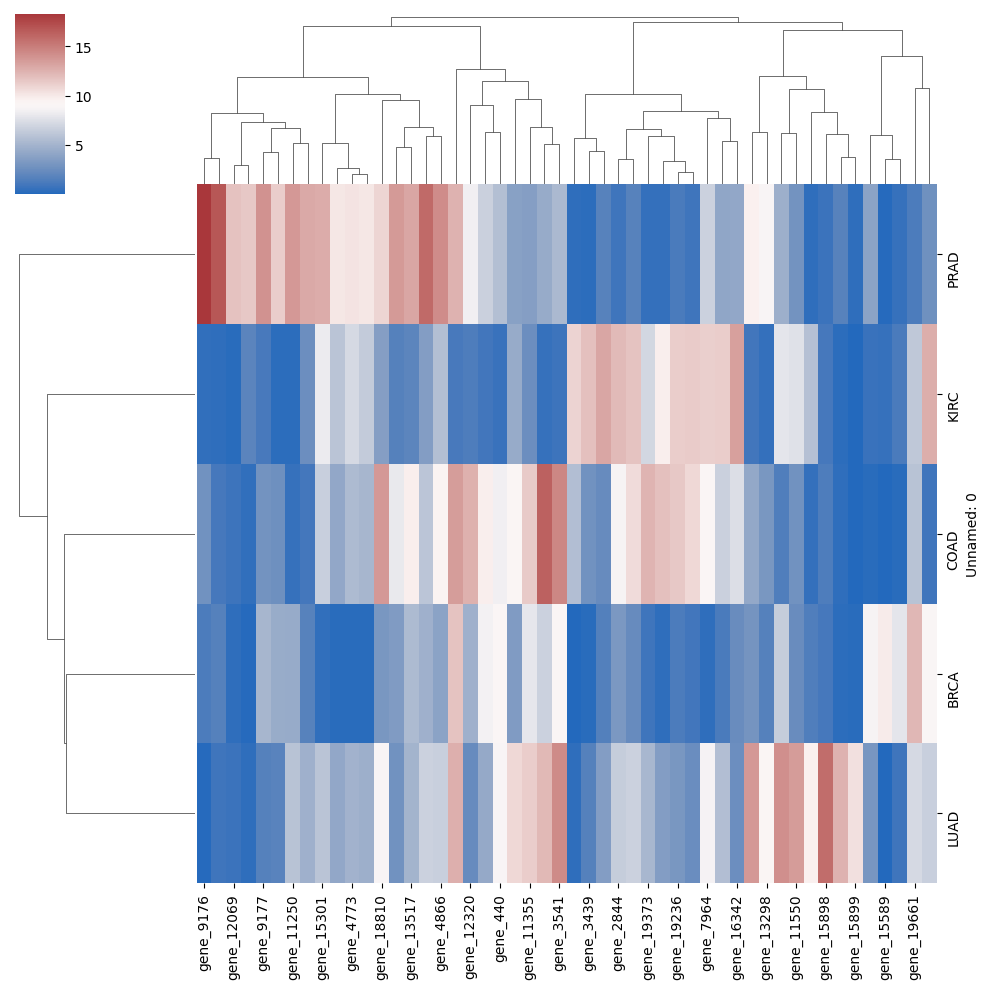

In [18]:
plt.figure(figsize=(12, 6))
sns.clustermap(heatmap_data, cmap = 'vlag')
plt.show()

# giảm chiều 

## PCA

In [19]:
scaler = StandardScaler()

In [20]:
X_vth_scaled = scaler.fit_transform(X_vth)

In [21]:
pca = PCA()
X_pca = pca.fit_transform(X_vth_scaled)

In [22]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

<function matplotlib.pyplot.show(close=None, block=None)>

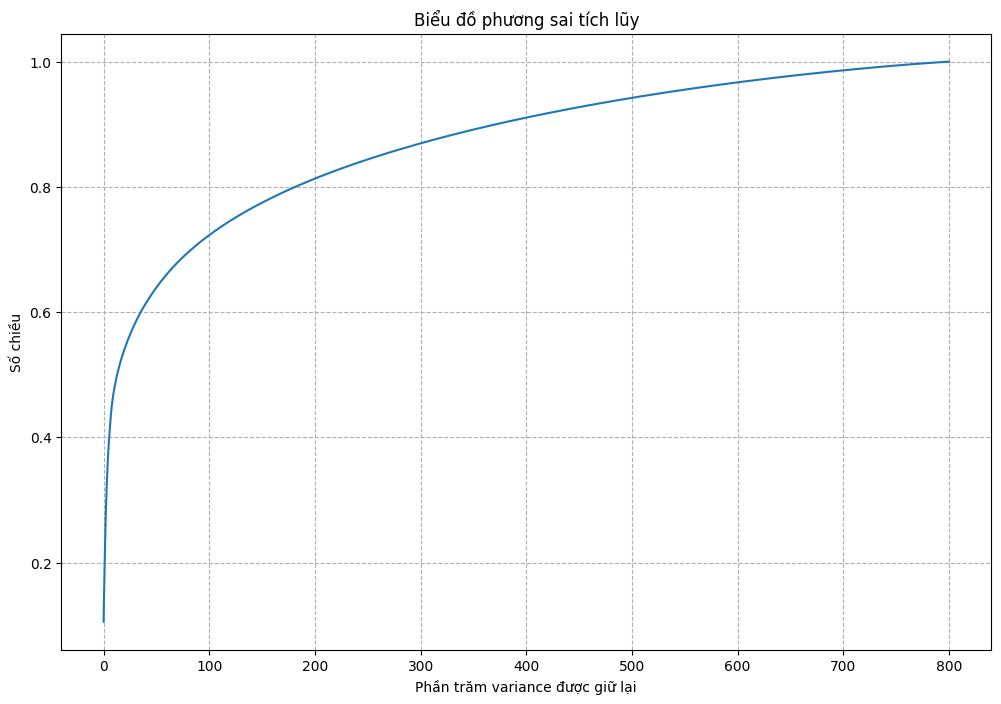

In [23]:
plt.figure(figsize=(12,8))
plt.plot(cum_var)
plt.grid(True, linestyle='--')
plt.ylabel('Số chiều')
plt.xlabel('Phần trăm variance được giữ lại')
plt.title('Biểu đồ phương sai tích lũy')
plt.show

In [24]:
le = LabelEncoder()
Y_encoded = le.fit_transform(Y_label)

In [25]:
pca_1 = PCA(n_components=350)
X_pca_1 = pca_1.fit_transform(X_vth_scaled)

In [26]:
pca_100 = PCA(n_components=100)
X_pca_100 = pca_100.fit_transform(X_vth_scaled)

## visualization pca

Text(0.5, 1.0, 'PCA visualization')

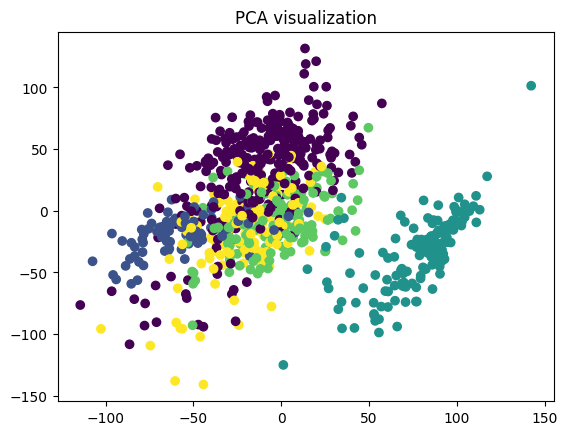

In [27]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_vth_scaled)

plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=Y_encoded)
plt.title("PCA visualization")

In [28]:
pca_10 = PCA(n_components = 6)
X_pca_10 = pca_10.fit_transform(X_vth_scaled)

In [29]:
pca_columns = [f'PC{i}' for i in range(1, 7)]
pca_df = pd.DataFrame(X_pca_10, columns = pca_columns)
pca_df['label'] = Y_label.values

In [30]:
pca_pairs = list(combinations(pca_columns, 2))

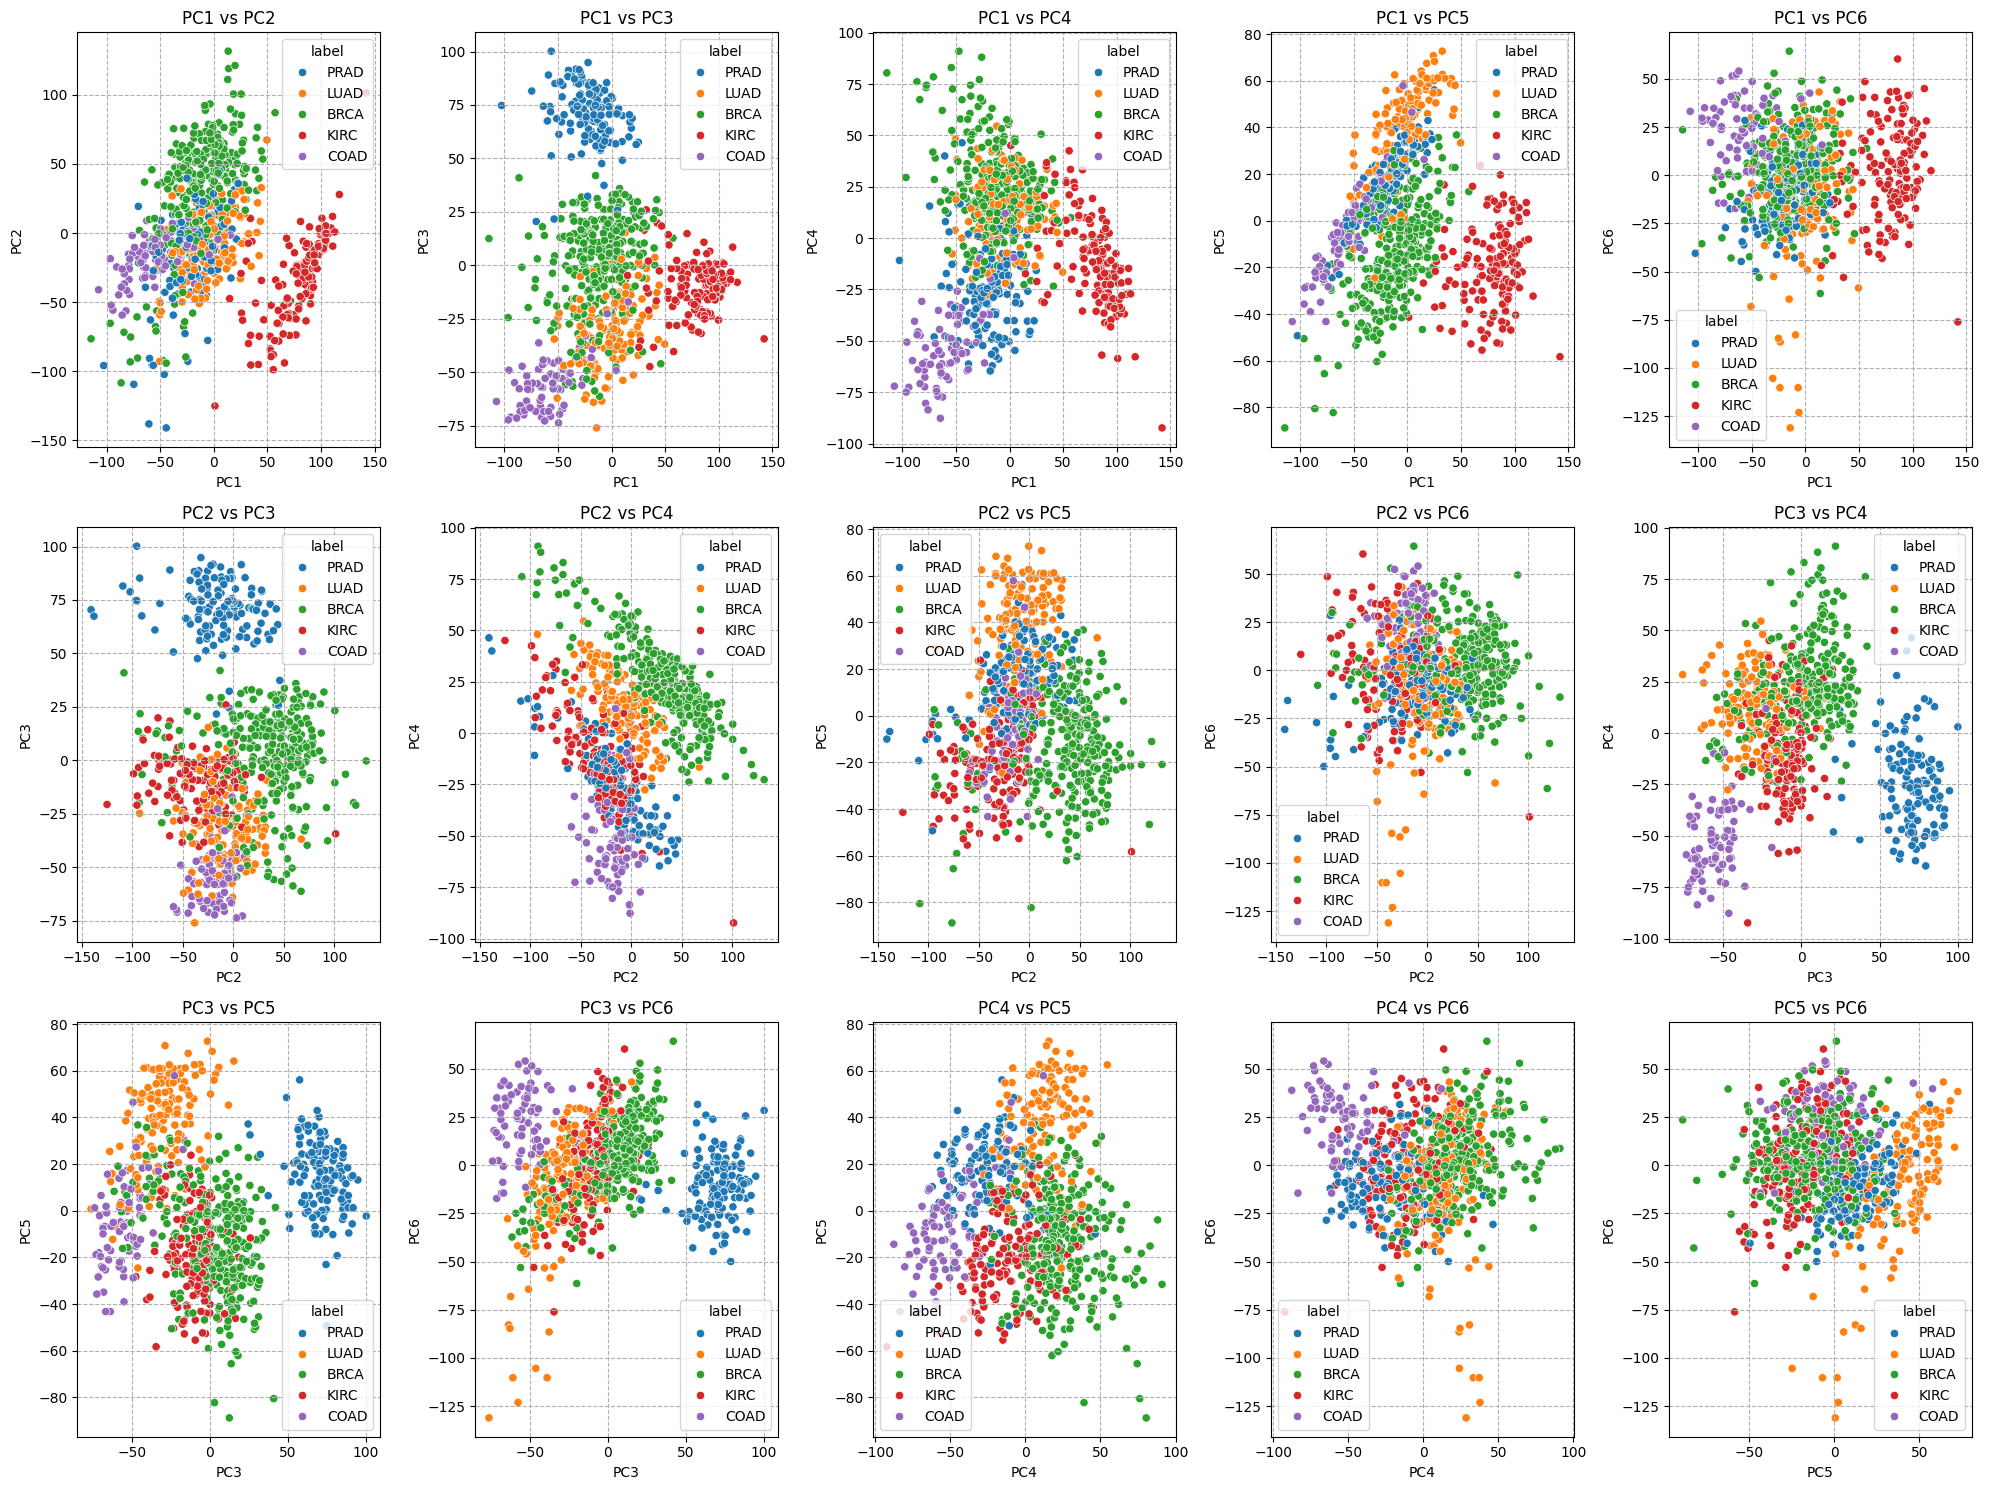

In [31]:
fig, axes = plt.subplots(nrows = 3, ncols = 5, figsize = (20, 15))
axes = axes.flatten()

for i, (pc1, pc2) in enumerate(pca_pairs):
    sns.scatterplot(
        data = pca_df,
        x = pc1,
        y = pc2,
        hue = 'label',
        ax = axes[i],
        legend = True,
        palette='tab10'
    )
    axes[i].set_title(f'{pc1} vs {pc2}')
    axes[i].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

## t-SNE

In [32]:
tsne = TSNE(
    n_components = 2,
    perplexity = 30,
    learning_rate = 200,
    random_state = 42
)

X_tsne = tsne.fit_transform(X_vth)

In [33]:
tsne_df = pd.DataFrame(X_tsne, columns = ['TSNE1', 'TSNE2'])
tsne_df['label'] = Y_label.values

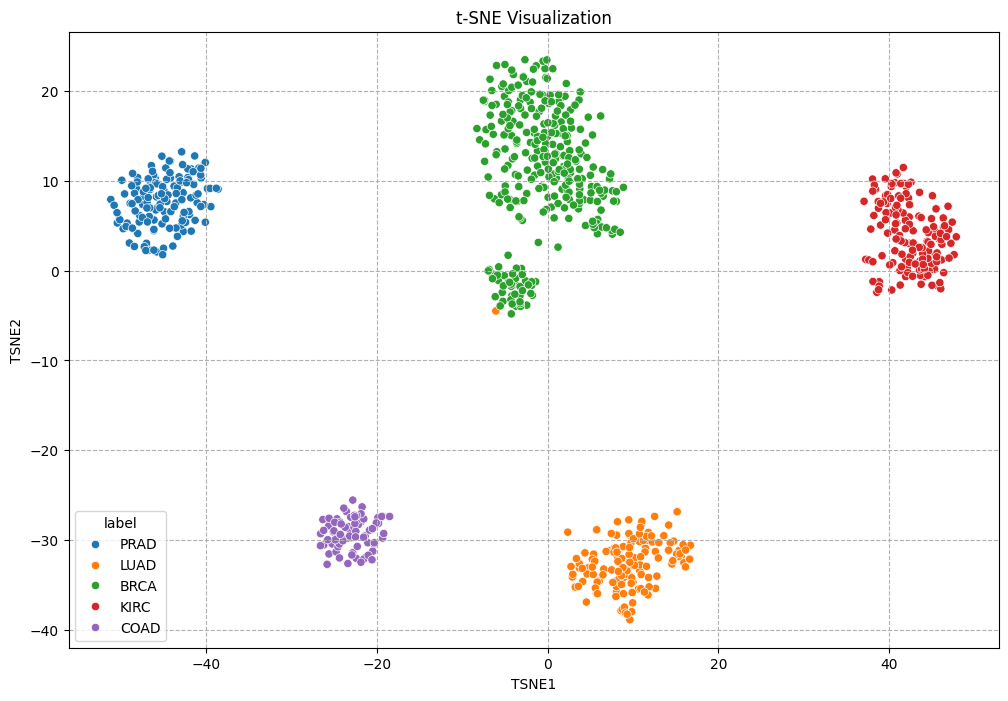

In [34]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data = tsne_df,
    x = 'TSNE1',
    y = 'TSNE2',
    hue = 'label',
    palette = 'tab10',
)
plt.title("t-SNE Visualization")
plt.grid(True, linestyle='--')
plt.show()

## UMAP

In [35]:
umap_model = umap.UMAP(
    n_components = 2,
    n_neighbors = 5,
    min_dist = 0.1,
    random_state = 42
)

X_umap = umap_model.fit_transform(X_vth)

C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [36]:
umap_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
umap_df['label'] = Y_label.values

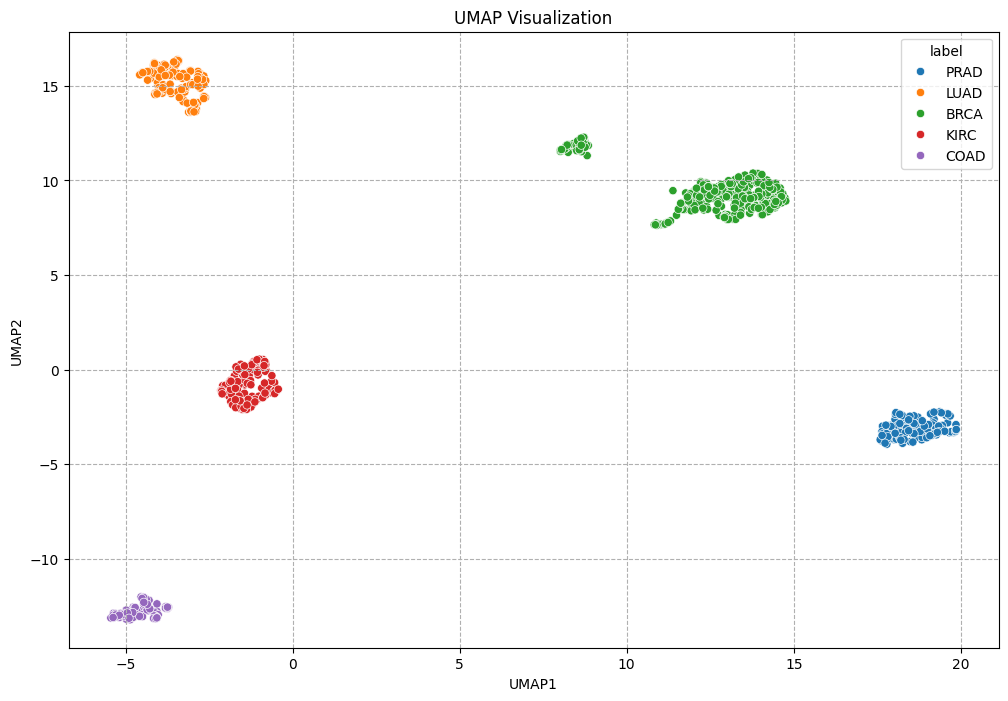

In [37]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data = umap_df,
    x='UMAP1',
    y='UMAP2',
    hue = 'label',
    palette = 'tab10',
)
plt.title("UMAP Visualization")
plt.grid(True, linestyle = '--')
plt.show()

# clustering

## K-means

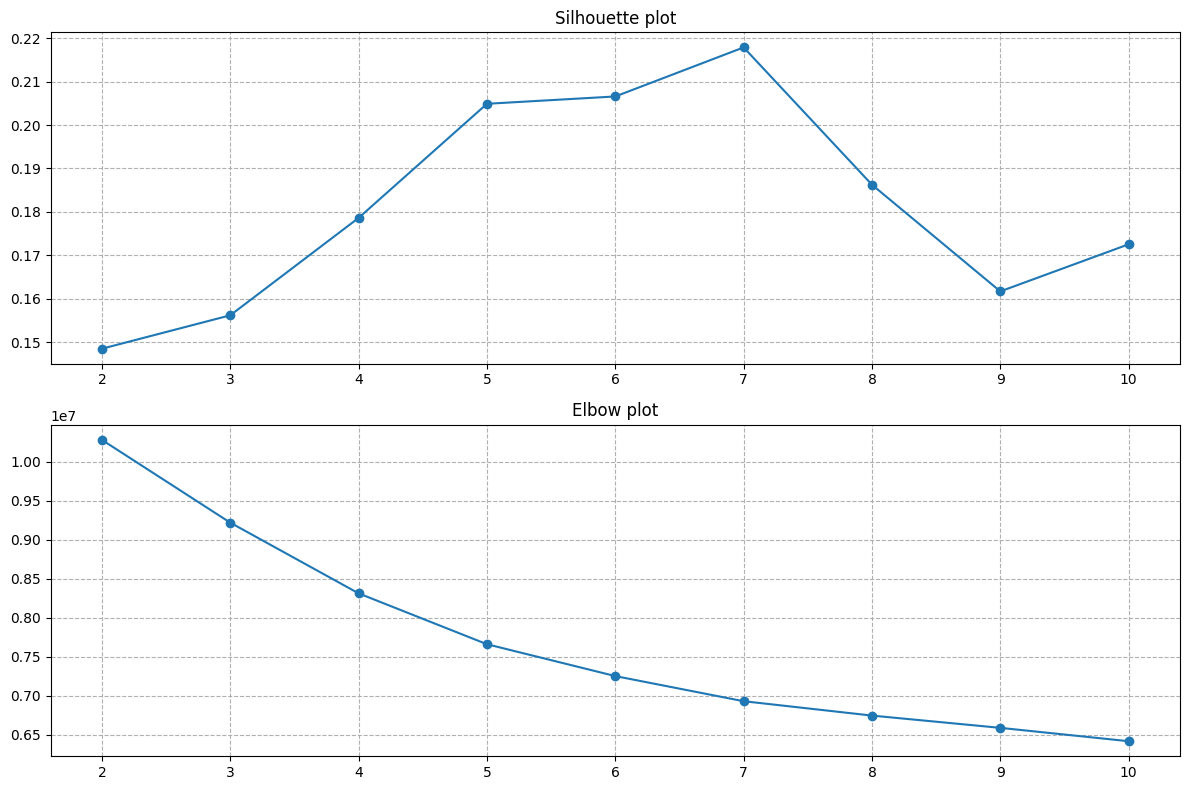

In [38]:
k_values = range(2, 11)
inertias = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    cluster_labels = kmeans.fit_predict(X_pca_100)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_pca_100, cluster_labels))

fig_1, axes_1 = plt.subplots(nrows = 2, ncols = 1, figsize = (12, 8))

axes_1[0].plot(list(k_values), sil_scores, marker = 'o')
axes_1[0].grid(True, linestyle = '--')
axes_1[0].set_title("Silhouette plot")
axes_1[1].plot(list(k_values), inertias, marker = 'o')
axes_1[1].grid(True, linestyle = '--')
axes_1[1].set_title("Elbow plot")

plt.tight_layout()
plt.show()

In [39]:
kmeans = KMeans(n_clusters = 5, init='k-means++', random_state = 42, n_init = 10)
cluster_labels = kmeans.fit_predict(X_pca_100)

In [40]:
sil = silhouette_score(X_pca_100, cluster_labels)
ari = adjusted_rand_score(Y_label, cluster_labels)
nmi = normalized_mutual_info_score(Y_label, cluster_labels)

print("\n===== KMEANS RESULTS =====")
print(f"Number of clusters: {kmeans.n_clusters}")
print(f"Silhouette Score: {sil:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")


===== KMEANS RESULTS =====
Number of clusters: 5
Silhouette Score: 0.2049
Adjusted Rand Index (ARI): 0.7941
Normalized Mutual Information (NMI): 0.8539



===== CROSSTAB: TRUE LABEL VS CLUSTER =====
Cluster      0    1    2   3    4
TrueLabel                        
0           53    0    0   0  247
1            4    0    0  74    0
2            2  144    0   0    0
3          139    0    0   0    2
4            1    0  134   0    1


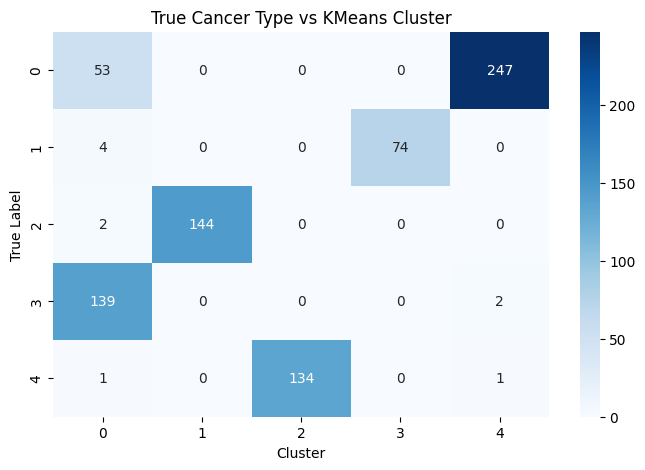

In [41]:
result_df = pd.DataFrame({
    'TrueLabel': Y_encoded,
    'Cluster': cluster_labels
})

cross_tab = pd.crosstab(result_df['TrueLabel'], result_df['Cluster'])
print("\n===== CROSSTAB: TRUE LABEL VS CLUSTER =====")
print(cross_tab)

plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title("True Cancer Type vs KMeans Cluster")
plt.xlabel("Cluster")
plt.ylabel("True Label")
plt.show()

In [42]:
plot_df = pd.DataFrame(X_pca_100[:, :2], columns=['PC1', 'PC2'])
plot_df['Cluster'] = cluster_labels
plot_df['TrueLabel'] = Y_encoded

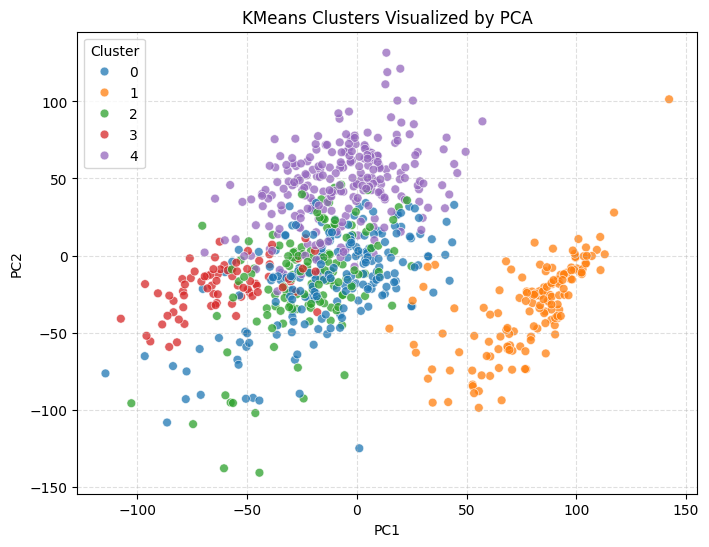

In [43]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10',
    alpha=0.75,
    s=40
)
plt.title("KMeans Clusters Visualized by PCA")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [44]:
df_kmeans = df.copy()
df_kmeans['kmeans_cluster'] = cluster_labels
df_kmeans['TrueLabel'] = Y_encoded

print(df_kmeans[['TrueLabel', 'kmeans_cluster']].head())

   TrueLabel  kmeans_cluster
0          4               2
1          3               0
2          4               2
3          4               2
4          0               4


## Hierarchical

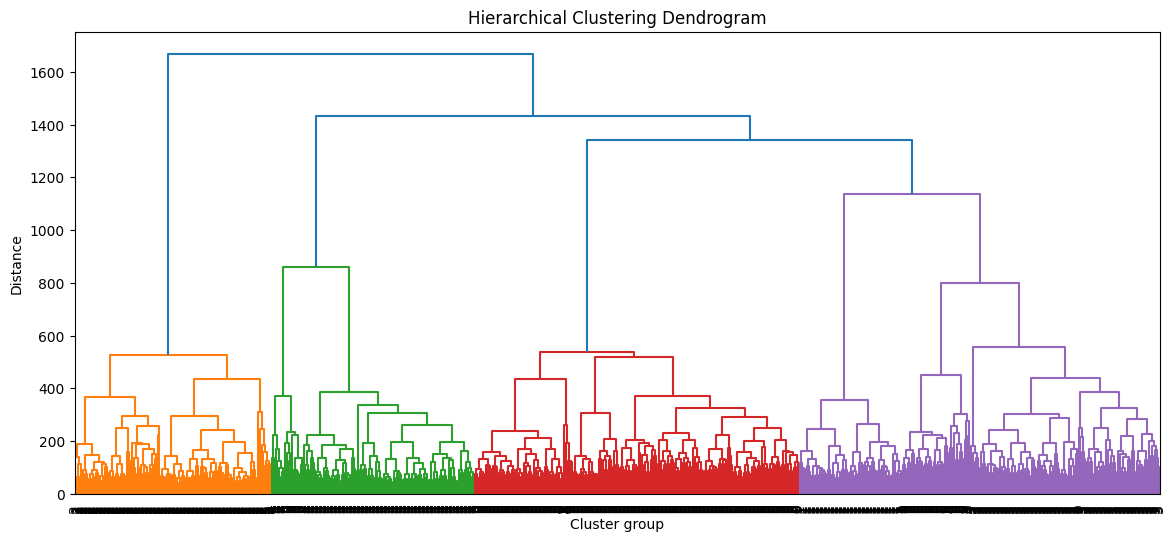

In [45]:
plt.figure(figsize=(14, 6))
Z = linkage(X_pca_100, method='ward')
dendrogram(Z, labels=Y_encoded, p=20, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster group")
plt.ylabel("Distance")
plt.show()

In [46]:
n_clusters = 5
hc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_vth_scaled)

In [47]:
sil = silhouette_score(X_pca_100, hc_labels)
ari = adjusted_rand_score(Y_label, hc_labels)
nmi = normalized_mutual_info_score(Y_label, hc_labels)

print("===== HIERARCHICAL CLUSTERING RESULTS =====")
print(f"Number of clusters: {n_clusters}")
print(f"Silhouette Score: {sil:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

===== HIERARCHICAL CLUSTERING RESULTS =====
Number of clusters: 5
Silhouette Score: 0.2005
Adjusted Rand Index (ARI): 0.7754
Normalized Mutual Information (NMI): 0.8333


In [48]:
result_df = pd.DataFrame({
    'TrueLabel': Y_encoded,
    'HC_Cluster': hc_labels
})

cross_tab = pd.crosstab(result_df['TrueLabel'], result_df['HC_Cluster'])

print("\n===== CROSSTAB: TRUE LABEL VS HIERARCHICAL CLUSTER =====")
print(cross_tab)


===== CROSSTAB: TRUE LABEL VS HIERARCHICAL CLUSTER =====
HC_Cluster    0    1    2    3   4
TrueLabel                         
0            14  239   47    0   0
1             0    0    1    0  77
2             0    1    0  145   0
3             1    1  139    0   0
4           134    1    1    0   0


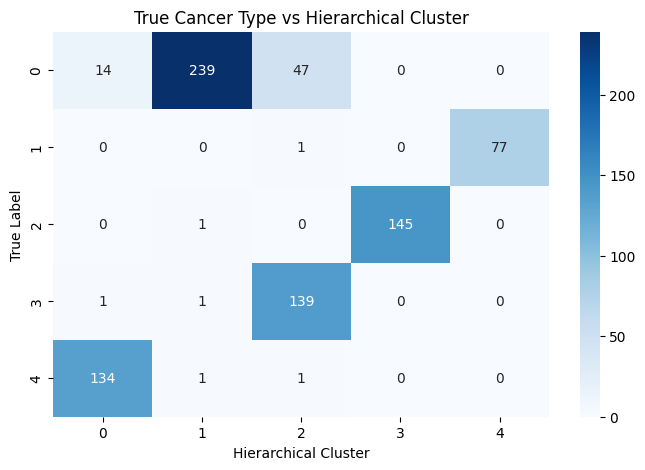

In [49]:
plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title("True Cancer Type vs Hierarchical Cluster")
plt.xlabel("Hierarchical Cluster")
plt.ylabel("True Label")
plt.show()

In [50]:
df_hc = df.copy()
df_hc['TrueLabel'] = Y_encoded
df_hc['hc_cluster'] = hc_labels

print("\n===== SAMPLE OUTPUT =====")
print(df_hc[['TrueLabel', 'hc_cluster']].head())


===== SAMPLE OUTPUT =====
   TrueLabel  hc_cluster
0          4           0
1          3           2
2          4           2
3          4           0
4          0           1


## DBSCAN

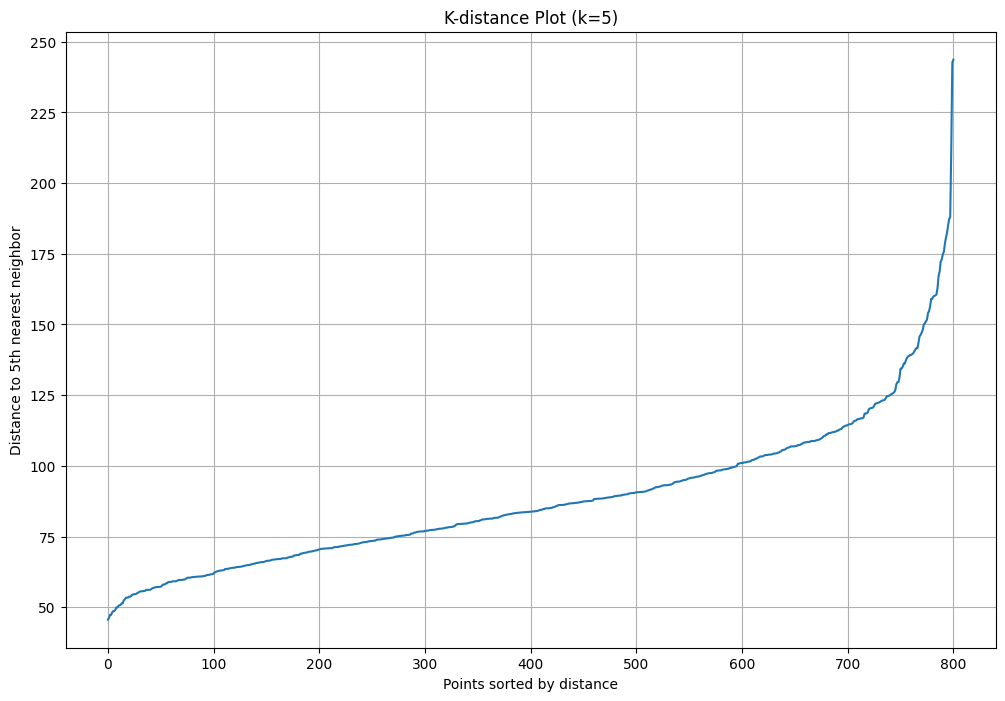

In [110]:
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_pca_100)
distances, indices = neighbors_fit.kneighbors(X_pca_100)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(12, 8))
plt.plot(k_distances)
plt.title(f'K-distance Plot (k={min_samples})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_samples}th nearest neighbor')
plt.grid(True)
plt.show()

In [126]:
dbscan = DBSCAN(eps=50, min_samples=5, metric='euclidean')
dbscan_labels = dbscan.fit_predict(X_pca_100)

In [127]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("===== DBSCAN RESULTS =====")
print(f"Estimated number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

===== DBSCAN RESULTS =====
Estimated number of clusters: 3
Number of noise points: 770


In [54]:
ari = adjusted_rand_score(Y_encoded, dbscan_labels)
nmi = normalized_mutual_info_score(Y_encoded, dbscan_labels)

mask = dbscan_labels != -1
labels_no_noise = dbscan_labels[mask]
X_no_noise = X_pca_100[mask]

if len(set(labels_no_noise)) >= 2:
    sil = silhouette_score(X_no_noise, labels_no_noise)
    print(f"Silhouette Score (without noise): {sil:.4f}")
else:
    sil = None
    print("Silhouette Score: Cannot compute (less than 2 non-noise clusters)")

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Silhouette Score (without noise): 0.3902
Adjusted Rand Index (ARI): 0.0165
Normalized Mutual Information (NMI): 0.0801


In [55]:
result_df = pd.DataFrame({
    'TrueLabel': Y_label,
    'DBSCAN_Cluster': dbscan_labels
})

print("\n===== SAMPLE OUTPUT =====")
print(result_df.head())


===== SAMPLE OUTPUT =====
  TrueLabel  DBSCAN_Cluster
0      PRAD              -1
1      LUAD              -1
2      PRAD              -1
3      PRAD              -1
4      BRCA              -1



===== CROSSTAB: TRUE LABEL VS DBSCAN CLUSTER =====
DBSCAN_Cluster   -1   0   1   2
TrueLabel                      
BRCA            300   0   0   0
COAD             78   0   0   0
KIRC            130   0  16   0
LUAD            141   0   0   0
PRAD            121  10   0   5


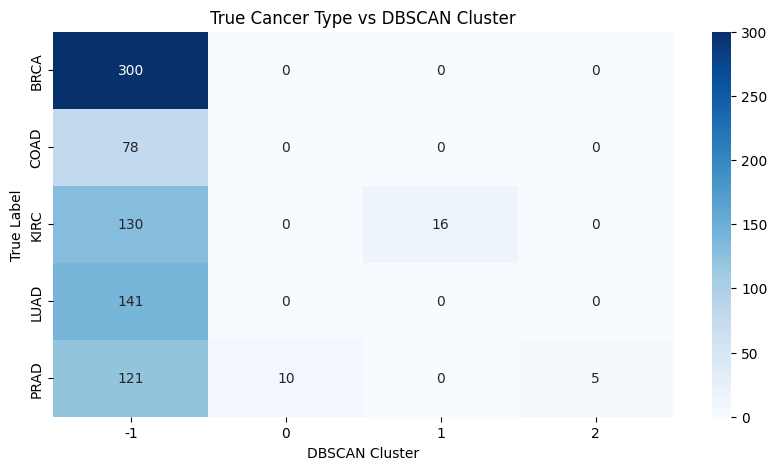

In [56]:
cross_tab = pd.crosstab(result_df['TrueLabel'], result_df['DBSCAN_Cluster'])

print("\n===== CROSSTAB: TRUE LABEL VS DBSCAN CLUSTER =====")
print(cross_tab)

# ===== 6. Heatmap =====
plt.figure(figsize=(10, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title("True Cancer Type vs DBSCAN Cluster")
plt.xlabel("DBSCAN Cluster")
plt.ylabel("True Label")
plt.show()

In [57]:
df_dbscan = df.copy()
df_dbscan['TrueLabel'] = Y_label
df_dbscan['dbscan_cluster'] = dbscan_labels

print("\n===== SAMPLE OUTPUT WITH ORIGINAL DF =====")
print(df_dbscan[['TrueLabel', 'dbscan_cluster']].head())


===== SAMPLE OUTPUT WITH ORIGINAL DF =====
  TrueLabel  dbscan_cluster
0      PRAD              -1
1      LUAD              -1
2      PRAD              -1
3      PRAD              -1
4      BRCA              -1


## Gaussian mixture

In [58]:
k_values = range(2, 11)

bic_scores = []
aic_scores = []
sil_scores = []
ari_scores = []
nmi_scores = []

for k in k_values:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='diag',   # thử 'full' trước
        random_state=42
    )
    
    cluster_labels = gmm.fit_predict(X_vth_scaled)
    
    bic_scores.append(gmm.bic(X_vth_scaled))
    aic_scores.append(gmm.aic(X_vth_scaled))
    sil_scores.append(silhouette_score(X_vth_scaled, cluster_labels))
    ari_scores.append(adjusted_rand_score(Y_label, cluster_labels))
    nmi_scores.append(normalized_mutual_info_score(Y_label, cluster_labels))

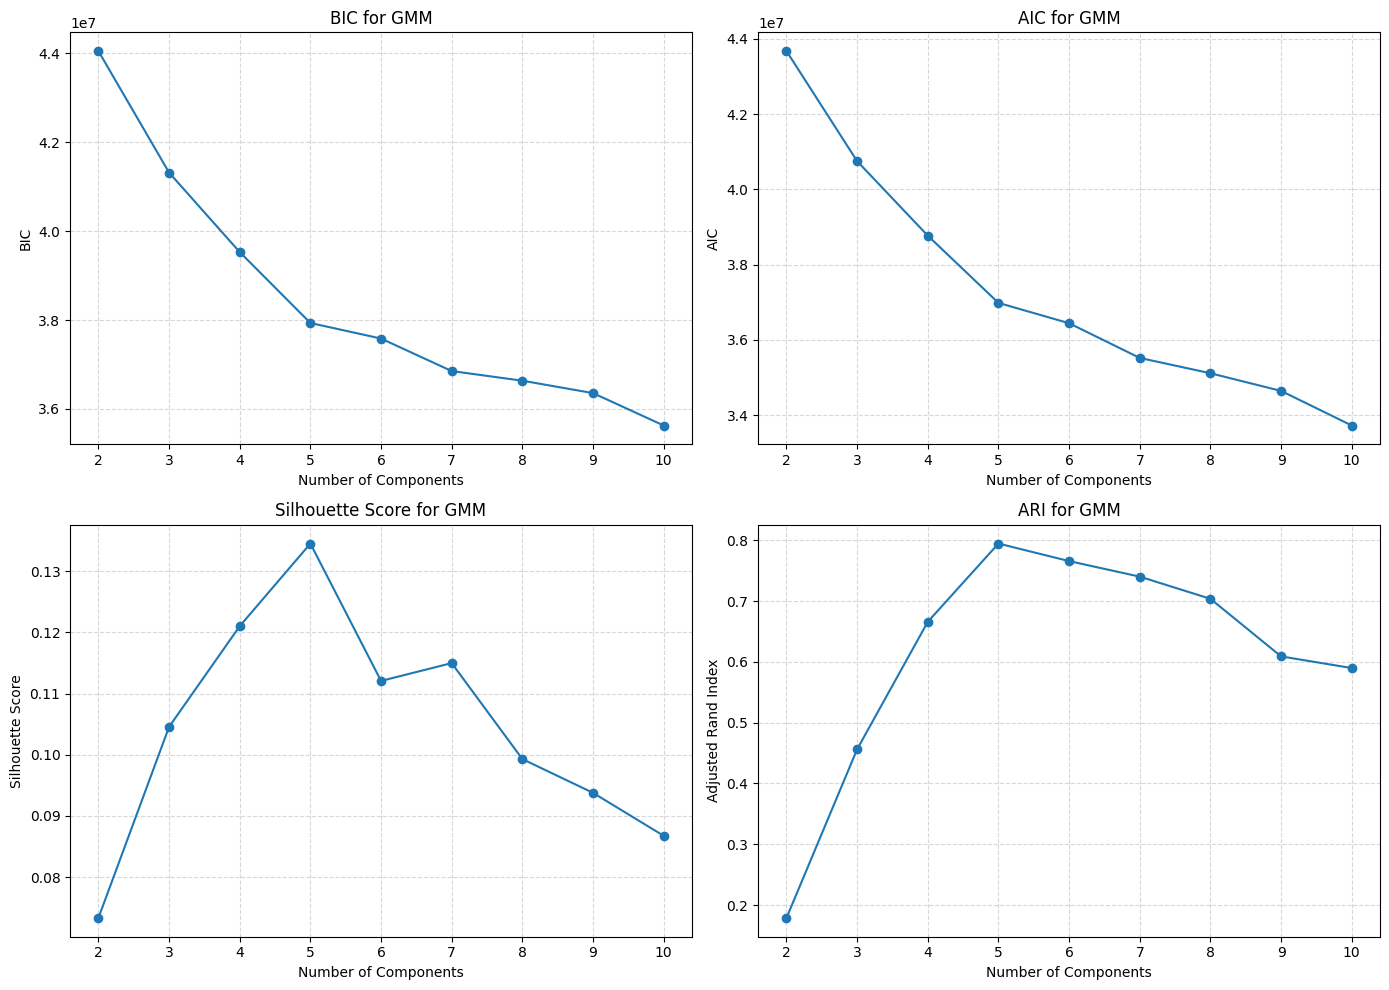

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# BIC
axes[0, 0].plot(list(k_values), bic_scores, marker='o')
axes[0, 0].set_title("BIC for GMM")
axes[0, 0].set_xlabel("Number of Components")
axes[0, 0].set_ylabel("BIC")
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# AIC
axes[0, 1].plot(list(k_values), aic_scores, marker='o')
axes[0, 1].set_title("AIC for GMM")
axes[0, 1].set_xlabel("Number of Components")
axes[0, 1].set_ylabel("AIC")
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Silhouette
axes[1, 0].plot(list(k_values), sil_scores, marker='o')
axes[1, 0].set_title("Silhouette Score for GMM")
axes[1, 0].set_xlabel("Number of Components")
axes[1, 0].set_ylabel("Silhouette Score")
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# ARI
axes[1, 1].plot(list(k_values), ari_scores, marker='o')
axes[1, 1].set_title("ARI for GMM")
axes[1, 1].set_xlabel("Number of Components")
axes[1, 1].set_ylabel("Adjusted Rand Index")
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [60]:
# =========================
# 7. CHAY GMM CHINH THUC
# =========================
# Có 2 cách:
# - theo domain knowledge: n_components = 5
# - theo BIC/AIC/ARI tốt nhất

n_components_final = 5

gmm_final = GaussianMixture(
    n_components=n_components_final,
    covariance_type='diag',
    random_state=42
)

cluster_labels = gmm_final.fit_predict(X_vth_scaled)

# Soft clustering: xác suất thuộc từng cụm
cluster_probs = gmm_final.predict_proba(X_vth_scaled)

# =========================
# 8. DANH GIA KET QUA
# =========================
sil = silhouette_score(X_vth_scaled, cluster_labels)
ari = adjusted_rand_score(Y_label, cluster_labels)
nmi = normalized_mutual_info_score(Y_label, cluster_labels)

print("\n===== GMM RESULTS =====")
print(f"Number of components: {n_components_final}")
print(f"BIC: {gmm_final.bic(X_vth_scaled):.4f}")
print(f"AIC: {gmm_final.aic(X_vth_scaled):.4f}")
print(f"Silhouette Score: {sil:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")



===== GMM RESULTS =====
Number of components: 5
BIC: 37932952.1513
AIC: 36983390.5455
Silhouette Score: 0.1345
Adjusted Rand Index (ARI): 0.7946
Normalized Mutual Information (NMI): 0.8477


In [61]:
n_components_final = 5

gmm_final = GaussianMixture(
    n_components=n_components_final,
    covariance_type='diag',
    random_state=42
)

cluster_labels = gmm_final.fit_predict(X_vth_scaled)
cluster_probs = gmm_final.predict_proba(X_vth_scaled)

In [62]:
sil = silhouette_score(X_vth_scaled, cluster_labels)
ari = adjusted_rand_score(Y_label, cluster_labels)
nmi = normalized_mutual_info_score(Y_label, cluster_labels)

print("\n===== GMM RESULTS =====")
print(f"Number of components: {n_components_final}")
print(f"BIC: {gmm_final.bic(X_vth_scaled):.4f}")
print(f"AIC: {gmm_final.aic(X_vth_scaled):.4f}")
print(f"Silhouette Score: {sil:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")


===== GMM RESULTS =====
Number of components: 5
BIC: 37932952.1513
AIC: 36983390.5455
Silhouette Score: 0.1345
Adjusted Rand Index (ARI): 0.7946
Normalized Mutual Information (NMI): 0.8477



===== CROSSTAB: TRUE LABEL VS CLUSTER =====
Cluster      0   1    2    3    4
TrueLabel                        
BRCA         0   0   50  250    0
COAD         0  74    4    0    0
KIRC         0   0    5    0  141
LUAD         0   0  140    1    0
PRAD       133   0    2    1    0


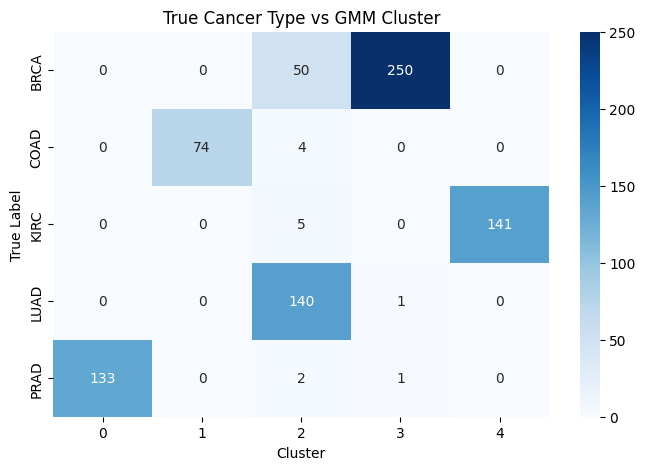

In [63]:
result_df = pd.DataFrame({
    'TrueLabel': Y_label,
    'Cluster': cluster_labels
})

cross_tab = pd.crosstab(result_df['TrueLabel'], result_df['Cluster'])
print("\n===== CROSSTAB: TRUE LABEL VS CLUSTER =====")
print(cross_tab)

plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title("True Cancer Type vs GMM Cluster")
plt.xlabel("Cluster")
plt.ylabel("True Label")
plt.show()

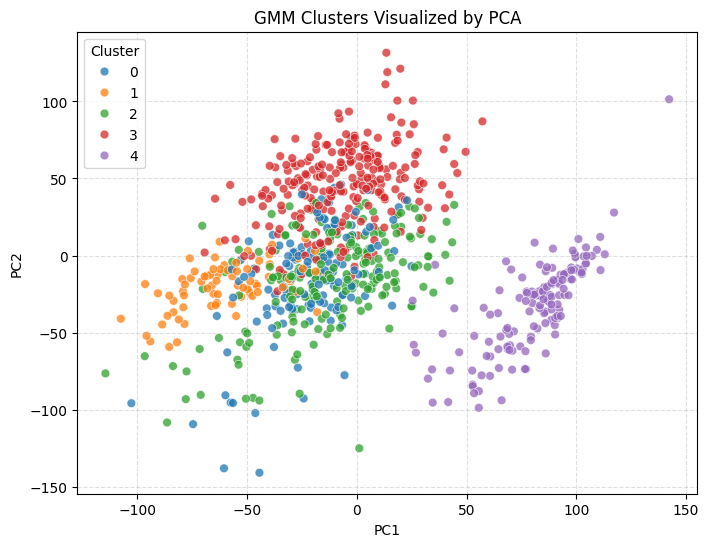

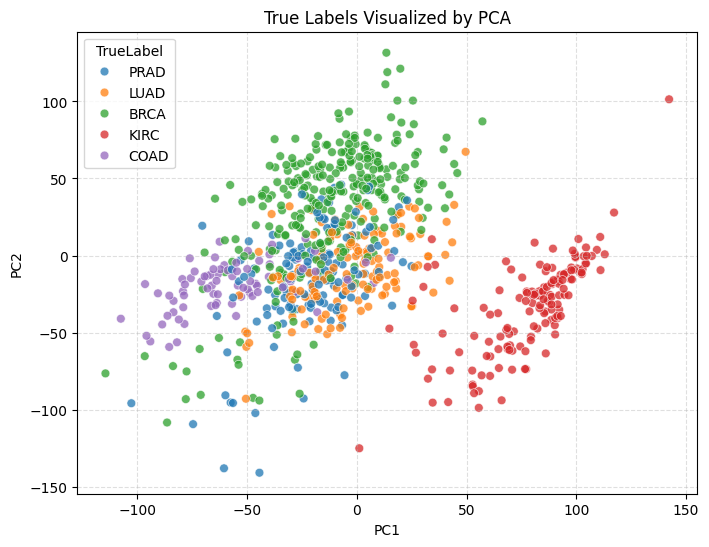

In [64]:
# =========================
# 10. PCA 2D DE TRUC QUAN HOA
# =========================
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_vth_scaled)

plot_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
plot_df['Cluster'] = cluster_labels
plot_df['TrueLabel'] = Y_label

# Plot theo cluster GMM
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10',
    alpha=0.75,
    s=40
)
plt.title("GMM Clusters Visualized by PCA")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Plot theo label thật
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='TrueLabel',
    palette='tab10',
    alpha=0.75,
    s=40
)
plt.title("True Labels Visualized by PCA")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


In [65]:
# =========================
# 11. XEM XAC SUAT THUOC CUM (SOFT CLUSTERING)
# =========================
proba_df = pd.DataFrame(
    cluster_probs,
    columns=[f'Cluster_{i}_prob' for i in range(n_components_final)]
)

print("\n===== FIRST 5 SAMPLES CLUSTER PROBABILITIES =====")
print(proba_df.head())

# =========================
# 12. GAN KET QUA VAO DATAFRAME GOC
# =========================
df_gmm = df.copy()
df_gmm['gmm_cluster'] = cluster_labels
df_gmm['TrueCluster'] = Y_encoded


print("\n===== SAMPLE OUTPUT =====")
print(df_gmm[['TrueCluster', 'gmm_cluster']].head())


===== FIRST 5 SAMPLES CLUSTER PROBABILITIES =====
   Cluster_0_prob  Cluster_1_prob  Cluster_2_prob  Cluster_3_prob  \
0             1.0             0.0             0.0             0.0   
1             0.0             0.0             1.0             0.0   
2             0.0             0.0             1.0             0.0   
3             1.0             0.0             0.0             0.0   
4             0.0             0.0             0.0             1.0   

   Cluster_4_prob  
0             0.0  
1             0.0  
2             0.0  
3             0.0  
4             0.0  

===== SAMPLE OUTPUT =====
   TrueCluster  gmm_cluster
0            4            0
1            3            2
2            4            2
3            4            0
4            0            3


## Spectral Clustering

In [66]:
k_values = range(2, 11)

sil_scores = []
ari_scores = []
nmi_scores = []

for k in k_values:
    spectral = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',   # rat hop voi data phi tuyen
        n_neighbors=10,
        assign_labels='kmeans',
        random_state=42
    )
    
    cluster_labels = spectral.fit_predict(X_pca)
    
    sil_scores.append(silhouette_score(X_pca, cluster_labels))
    ari_scores.append(adjusted_rand_score(Y_label, cluster_labels))
    nmi_scores.append(normalized_mutual_info_score(Y_label, cluster_labels))

C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\cluster\_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(
C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\cluster\_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(
C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\cluster\_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from 

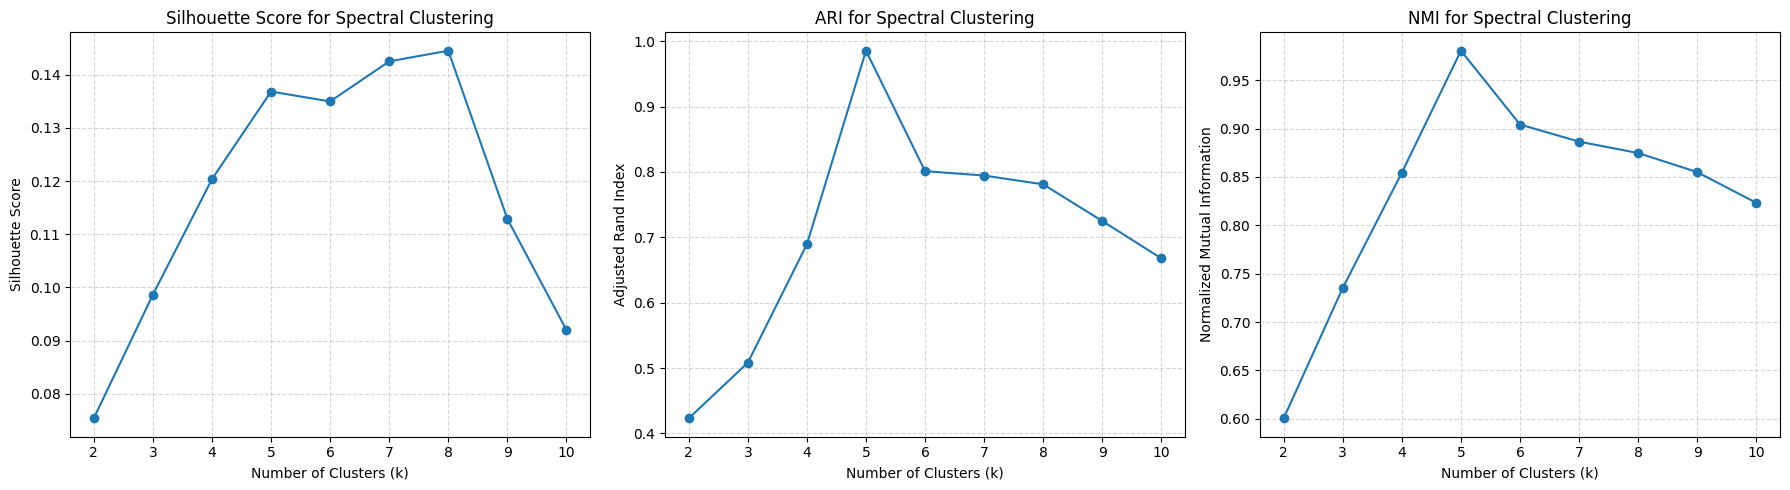

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette
axes[0].plot(list(k_values), sil_scores, marker='o')
axes[0].set_title("Silhouette Score for Spectral Clustering")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Silhouette Score")
axes[0].grid(True, linestyle='--', alpha=0.5)

# ARI
axes[1].plot(list(k_values), ari_scores, marker='o')
axes[1].set_title("ARI for Spectral Clustering")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Adjusted Rand Index")
axes[1].grid(True, linestyle='--', alpha=0.5)

# NMI
axes[2].plot(list(k_values), nmi_scores, marker='o')
axes[2].set_title("NMI for Spectral Clustering")
axes[2].set_xlabel("Number of Clusters (k)")
axes[2].set_ylabel("Normalized Mutual Information")
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [68]:
k_final = 5

spectral_final = SpectralClustering(
    n_clusters=k_final,
    affinity='nearest_neighbors',
    n_neighbors=10,
    assign_labels='kmeans',
    random_state=42
)

cluster_labels = spectral_final.fit_predict(X_pca)

C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\cluster\_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(


In [69]:
sil = silhouette_score(X_pca, cluster_labels)
ari = adjusted_rand_score(Y_label, cluster_labels)
nmi = normalized_mutual_info_score(Y_label, cluster_labels)

print("\n===== SPECTRAL CLUSTERING RESULTS =====")
print(f"Number of clusters: {k_final}")
print(f"Silhouette Score: {sil:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")


===== SPECTRAL CLUSTERING RESULTS =====
Number of clusters: 5
Silhouette Score: 0.1368
Adjusted Rand Index (ARI): 0.9855
Normalized Mutual Information (NMI): 0.9804



===== CROSSTAB: TRUE LABEL VS CLUSTER =====
Cluster      0    1    2    3   4
TrueLabel                        
0            0  300    0    0   0
1            0    1    0    0  77
2            0    1  145    0   0
3          139    2    0    0   0
4            0    0    0  136   0


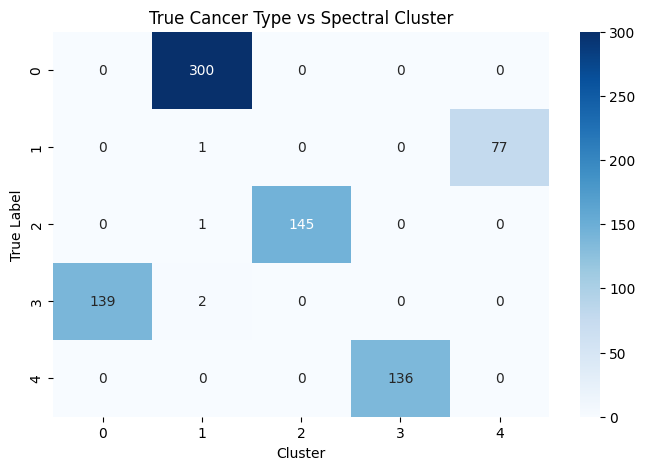

In [70]:
result_df = pd.DataFrame({
    'TrueLabel': Y_encoded,
    'Cluster': cluster_labels
})

cross_tab = pd.crosstab(result_df['TrueLabel'], result_df['Cluster'])
print("\n===== CROSSTAB: TRUE LABEL VS CLUSTER =====")
print(cross_tab)

plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title("True Cancer Type vs Spectral Cluster")
plt.xlabel("Cluster")
plt.ylabel("True Label")
plt.show()

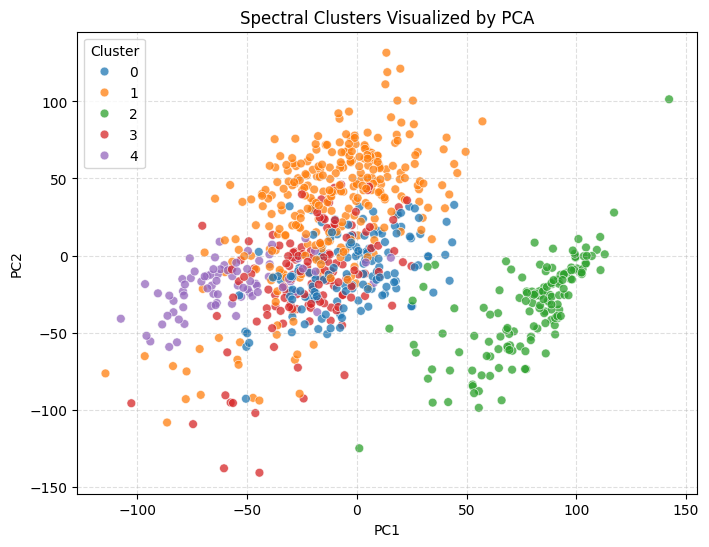

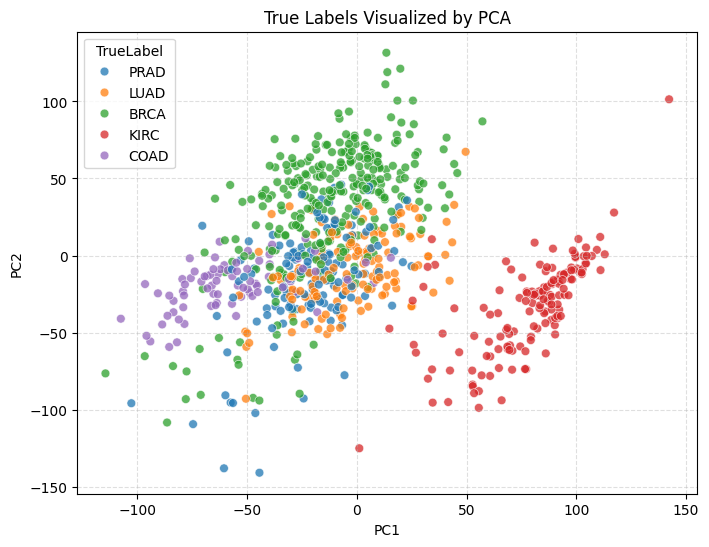

In [71]:
pca_2d = PCA(n_components=2, random_state=42)
X_vis = pca_2d.fit_transform(X_vth_scaled)

plot_df = pd.DataFrame(X_vis, columns=['PC1', 'PC2'])
plot_df['Cluster'] = cluster_labels
plot_df['TrueLabel'] = Y_label

# Plot theo cluster du doan
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10',
    alpha=0.75,
    s=40
)
plt.title("Spectral Clusters Visualized by PCA")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Plot theo label that
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='TrueLabel',
    palette='tab10',
    alpha=0.75,
    s=40
)
plt.title("True Labels Visualized by PCA")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [72]:
df_spectral = df.copy()
df_spectral['spectral_cluster'] = cluster_labels
df_spectral['true_label'] = Y_encoded

print("\n===== SAMPLE OUTPUT =====")
print(df_spectral[['true_label', 'spectral_cluster']].head())


===== SAMPLE OUTPUT =====
   true_label  spectral_cluster
0           4                 3
1           3                 0
2           4                 3
3           4                 3
4           0                 1


# Classification

## Logistic Regression

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vth_scaled, Y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=Y_encoded
)

In [120]:
model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs'
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [121]:
y_pred = model.predict(X_test)

In [122]:
acc = accuracy_score(y_test, y_pred)

print("\n===== LOGISTIC REGRESSION RESULTS =====")
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


===== LOGISTIC REGRESSION RESULTS =====
Accuracy: 0.9813664596273292

Classification Report:
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       0.94      0.94      0.94        16
        KIRC       1.00      1.00      1.00        30
        LUAD       0.96      0.93      0.95        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.98      0.97      0.97       161
weighted avg       0.98      0.98      0.98       161



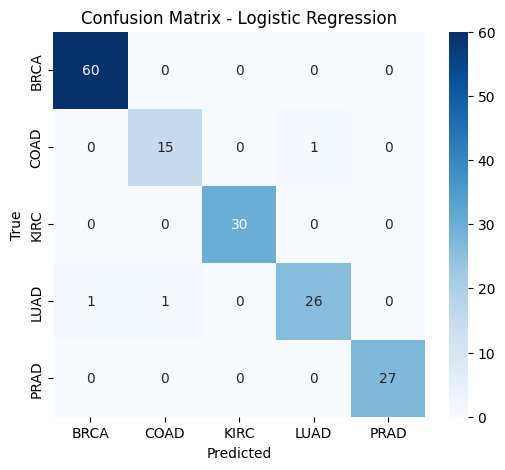

In [123]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## SVM

In [78]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    random_state=42
)

svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [79]:
y_pred = svm_model.predict(X_test)

In [80]:
acc = accuracy_score(y_test, y_pred)

print("\n===== LINEAR SVM RESULTS =====")
print(f"Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


===== LINEAR SVM RESULTS =====
Accuracy: 0.9814

Classification Report:
              precision    recall  f1-score   support

        BRCA       0.95      1.00      0.98        60
        COAD       1.00      0.94      0.97        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.93      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.99      0.97      0.98       161
weighted avg       0.98      0.98      0.98       161



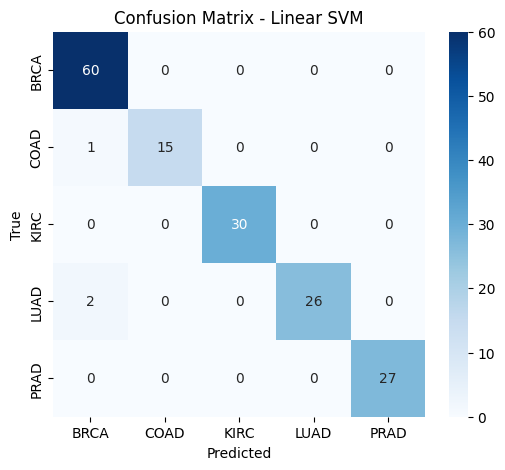

In [81]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

## Random Forest

### none pca

In [82]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [83]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)


===== RANDOM FOREST + PCA RESULTS =====
Accuracy: 0.9876
F1-macro: 0.9893
              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.93      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



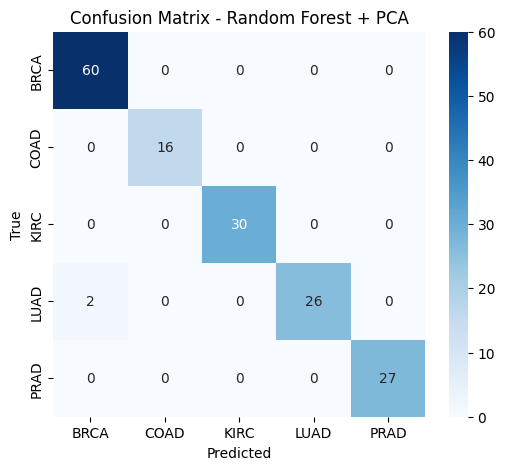

In [90]:
f1_macro = f1_score(y_test, y_pred, average='macro')
acc = accuracy_score(y_test, y_pred)
print("\n===== RANDOM FOREST + PCA RESULTS =====")
print(f"Accuracy: {acc:.4f}")
print(f"F1-macro: {f1_macro:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Random Forest + PCA")
plt.show()

### pca

In [91]:
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, Y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=Y_encoded
)

In [92]:
rf.fit(X_pca_train, y_train)
y_pca_pred = rf.predict(X_pca_test)


===== RANDOM FOREST + PCA RESULTS =====
Accuracy: 0.9876
F1-macro: 0.9893
              precision    recall  f1-score   support

        BRCA       0.68      1.00      0.81        60
        COAD       1.00      0.50      0.67        16
        KIRC       1.00      0.80      0.89        30
        LUAD       1.00      0.57      0.73        28
        PRAD       1.00      0.93      0.96        27

    accuracy                           0.83       161
   macro avg       0.94      0.76      0.81       161
weighted avg       0.88      0.83      0.82       161



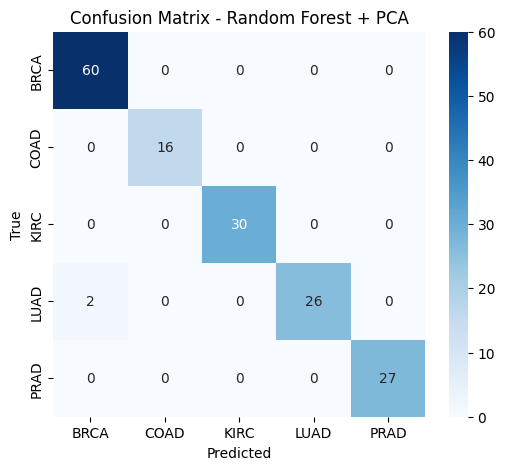

In [93]:
print("\n===== RANDOM FOREST + PCA RESULTS =====")
print(f"Accuracy: {acc:.4f}")
print(f"F1-macro: {f1_macro:.4f}")
print(classification_report(y_pca_test, y_pca_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Random Forest + PCA")
plt.show()

## XGBoost

In [94]:
xgb_model = XGBClassifier(
    objective='multi:softmax',   # multi-class classification
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

In [95]:
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

In [96]:
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print("\n===== XGBOOST RESULTS =====")
print(f"Accuracy: {acc:.4f}")
print(f"F1-macro: {f1_macro:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


===== XGBOOST RESULTS =====
Accuracy: 0.9938
F1-macro: 0.9947

Classification Report:
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161




===== TOP 20 IMPORTANT GENES =====
gene_5657     0.067683
gene_15864    0.051801
gene_2636     0.050399
gene_7999     0.045620
gene_12959    0.040539
gene_7228     0.039642
gene_18492    0.036847
gene_6723     0.035728
gene_7949     0.031501
gene_15866    0.028527
gene_2035     0.028507
gene_3438     0.027967
gene_1856     0.027350
gene_201      0.026027
gene_15863    0.025912
gene_9159     0.024909
gene_7411     0.021668
gene_3437     0.019649
gene_11880    0.019254
gene_17547    0.017617
dtype: float32


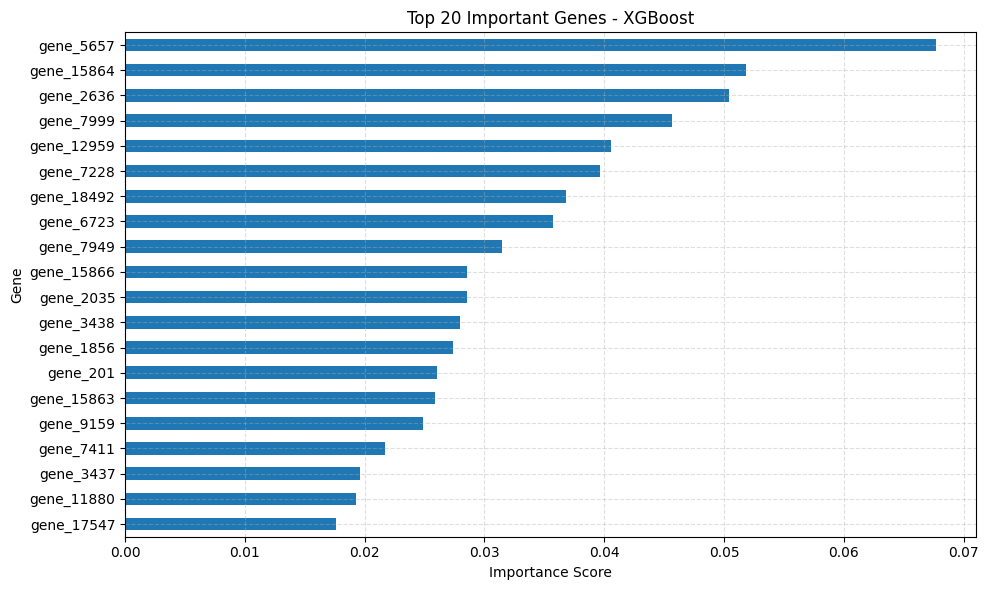

In [97]:
feature_names = [f'gene_{i}' for i in range(X_vth_scaled.shape[1])]
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("\n===== TOP 20 IMPORTANT GENES =====")
print(feature_importance.head(20))

plt.figure(figsize=(10, 6))
feature_importance.head(20).sort_values().plot(kind='barh')
plt.title("Top 20 Important Genes - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Gene")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [98]:
result_df = pd.DataFrame({
    'TrueLabel': le.inverse_transform(y_test),
    'PredictedLabel': le.inverse_transform(y_pred)
})

print("\n===== SAMPLE PREDICTIONS =====")
print(result_df.head())


===== SAMPLE PREDICTIONS =====
  TrueLabel PredictedLabel
0      KIRC           KIRC
1      BRCA           BRCA
2      BRCA           BRCA
3      PRAD           PRAD
4      KIRC           KIRC


## Neural network

### none scaled pca

In [101]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.0001,         # regularization
    batch_size='auto',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    early_stopping=True,  # giup giam overfitting
    validation_fraction=0.1,
    n_iter_no_change=10
)

In [102]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_vth, Y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=Y_encoded
)

In [103]:
mlp_model.fit(X_train1, y_train1)
y_pred1 = mlp_model.predict(X_test1)

In [104]:
acc = accuracy_score(y_test1, y_pred1)
f1_macro = f1_score(y_test1, y_pred1, average='macro')

print("\n===== NEURAL NETWORK RESULTS =====")
print(f"Accuracy: {acc:.4f}")
print(f"F1-macro: {f1_macro:.4f}")

print("\nClassification Report:")
print(classification_report(y_test1, y_pred1, target_names=le.classes_))


===== NEURAL NETWORK RESULTS =====
Accuracy: 0.9814
F1-macro: 0.9792

Classification Report:
              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      0.94      0.97        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.93      0.96        28
        PRAD       0.96      1.00      0.98        27

    accuracy                           0.98       161
   macro avg       0.99      0.97      0.98       161
weighted avg       0.98      0.98      0.98       161



### scaled

In [105]:
mlp_model.fit(X_train, y_train)
y_pred = mlp_model.predict(X_test)

In [106]:
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print("\n===== NEURAL NETWORK RESULTS =====")
print(f"Accuracy: {acc:.4f}")
print(f"F1-macro: {f1_macro:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


===== NEURAL NETWORK RESULTS =====
Accuracy: 0.9814
F1-macro: 0.9777

Classification Report:
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      0.94      0.97        16
        KIRC       0.97      1.00      0.98        30
        LUAD       0.96      0.93      0.95        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.98      0.97      0.98       161
weighted avg       0.98      0.98      0.98       161



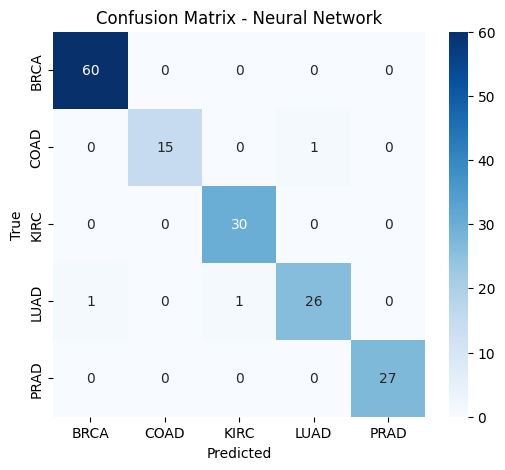

In [107]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Neural Network")
plt.show()

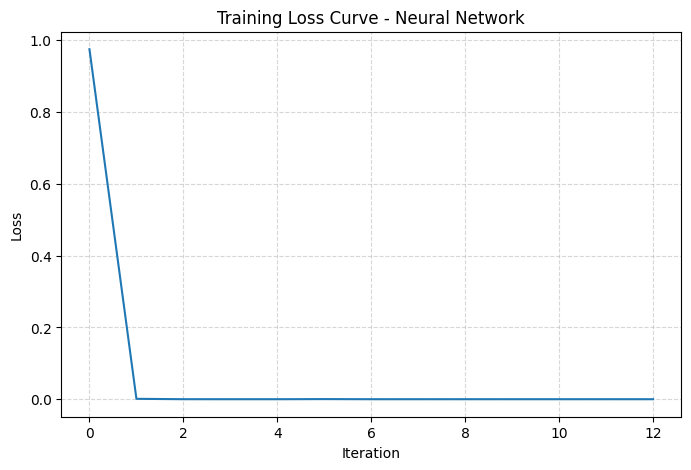

In [108]:
plt.figure(figsize=(8, 5))
plt.plot(mlp_model.loss_curve_)
plt.title("Training Loss Curve - Neural Network")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [109]:
result_df = pd.DataFrame({
    'TrueLabel': le.inverse_transform(y_test),
    'PredictedLabel': le.inverse_transform(y_pred)
})

print("\n===== SAMPLE PREDICTIONS =====")
print(result_df.head())


===== SAMPLE PREDICTIONS =====
  TrueLabel PredictedLabel
0      KIRC           KIRC
1      BRCA           BRCA
2      BRCA           BRCA
3      PRAD           PRAD
4      KIRC           KIRC
